# Reconhecimento de Dígitos MNIST com Perceptron Multicamadas (MLP)
Este notebook implementa uma Rede Neural do tipo Multilayer Perceptron (MLP) para classificar imagens de dígitos manuscritos (0-9) da base de dados MNIST.

O objetivo é transformar cada imagem de 28×28 pixels em um vetor de 784 entradas e passá-lo por camadas ocultas para que a rede aprenda padrões complexos e consiga prever o número correto. E vamos fazer isso com a biblioteca PyTorch


Eu adaptei meu código para os mesmos parâmetros que o resto da turma, a principal mudança é a base de dados e como a tratamos, antes eu estava treinando "diretamente" com imagens que estavam salvas em pastas, o que demorava muito mais. Cheguei a conclusão que essa não era a forma mais eficiente, o que demonstra a importancia do pré-processamento. Espero que nos próximos trabalhos eu possa explorar mais e fazer de forma melhor.

## Biblioteca

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import time
import numpy as np

# Configuração de dispositivo (GPU se disponível, caso contrário CPU)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Executando em: {DEVICE}")

Executando em: cuda


## Base de Dados (MNIST)

Diferente do código anterior que baixava um arquivo .tgz, aqui utilizaremos o carregador oficial que garante a integridade dos dados e facilita a divisão de treino/validação de 20%
- Transform: Normalizamos os pixels (0-255) para uma escala entre 0 e 1.
- Validation Split: Reservamos 12.000 imagens (20% de 60.000) para validar se a rede está aprendendo ou apenas "decorando" (overfitting).

In [2]:
train_transform = transforms.Compose([
    transforms.RandomAffine(degrees=10, translate=(0.1, 0.1), scale=(0.9, 1.1)),
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

val_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

# 1. Transformação: Converte para tensor e normaliza
transform = transforms.Compose([
    transforms.ToTensor(),
])

# 2. Carrega o conjunto de treino completo (60.000 imagens)
full_train_dataset = datasets.MNIST(root='./data', train=True, download=True, transform=transform)

# 3. Divisão Padronizada: 80% treino (48k) / 20% validação (12k)
train_size = int(0.8 * len(full_train_dataset))
val_size = len(full_train_dataset) - train_size
train_dataset, val_dataset = random_split(full_train_dataset, [train_size, val_size])

# 4. Conjunto de teste (10.000 imagens)
test_dataset = datasets.MNIST(root='./data', train=False, download=True, transform=transform)

# 5. DataLoaders com Batch Size de 256
BATCH_SIZE = 256
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

print(f"Treino: {len(train_dataset)} imagens | Validação: {len(val_dataset)} imagens")

100%|██████████| 9.91M/9.91M [00:00<00:00, 18.6MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 490kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.66MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 13.4MB/s]

Treino: 48000 imagens | Validação: 12000 imagens


## Arquitetura da Rede (O Modelo)

- Entrada: 784 neurônios (28×28).
- Camada Oculta 1: 256 neurônios + ativação ReLU.
- Camada Oculta 2: 128 neurônios + ativação ReLU.
- Saída: 10 neurônios (um para cada dígito).

In [3]:
class PerceptronMNIST(nn.Module):
    def __init__(self):
        super(PerceptronMNIST, self).__init__()
        self.flatten = nn.Flatten()

        # Camada 1: 784 -> 256 com Normalização
        self.fc1 = nn.Linear(784, 256)
        self.bn1 = nn.BatchNorm1d(256)

        # Camada 2: 256 -> 128 com Normalização
        self.fc2 = nn.Linear(256, 128)
        self.bn2 = nn.BatchNorm1d(128)

        # O "segurança" que apaga 30% dos neurônios aleatoriamente
        self.dropout = nn.Dropout(p=0.3)

        self.fc3 = nn.Linear(128, 10)

    def forward(self, x):
        x = self.flatten(x)
        # Ativação -> Normalização -> Dropout
        x = F.relu(self.bn1(self.fc1(x)))
        x = self.dropout(x)

        x = F.relu(self.bn2(self.fc2(x)))
        x = self.dropout(x)

        return self.fc3(x)

model = PerceptronMNIST().to(DEVICE)

## Configuração do Treinamento e Loop de Treinamento e Validação
- Otimizador Adam: Ajusta os pesos de forma eficiente.
- Taxa de Aprendizado (LR): 0.001.
- Loss Function: CrossEntropyLoss (Equivalente ao Sparse Categorical Crossentropy no PyTorch).

In [4]:
# Voltando para o LR que funcionava no seu gráfico de bolinhas
LEARNING_RATE = 0.001
BATCH_SIZE = 256
EPOCHS = 10

# Normalização idêntica à do primeiro código
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

# Configura a "regra do jogo"
criterion = nn.CrossEntropyLoss(label_smoothing=0.1) # Evita que a rede fique "viciada"
#criterion = nn.CrossEntropyLoss() # Evita que a rede fique "viciada"
optimizer = optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=1e-2)

# O Scheduler: ele vigia a perda de validação
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3)

In [5]:
history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}

start_time = time.perf_counter()

for epoch in range(EPOCHS):
    # --- FASE DE TREINO ---
    model.train()
    train_loss, train_correct = 0, 0
    for images, labels in train_loader:
        images, labels = images.to(DEVICE), labels.to(DEVICE)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        train_loss += loss.item()
        train_correct += (outputs.argmax(1) == labels).sum().item()

    # --- FASE DE VALIDAÇÃO ---
    model.eval()
    val_loss, val_correct = 0, 0
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(DEVICE), labels.to(DEVICE)
            outputs = model(images)
            loss = criterion(outputs, labels)
            val_loss += loss.item()
            val_correct += (outputs.argmax(1) == labels).sum().item()

    # Métricas
    epoch_train_acc = 100 * train_correct / len(train_dataset)
    epoch_val_acc = 100 * val_correct / len(val_dataset)

    history["train_loss"].append(train_loss / len(train_loader))
    history["val_loss"].append(val_loss / len(val_loader))
    history["train_acc"].append(epoch_train_acc)
    history["val_acc"].append(epoch_val_acc)

    print(f"Época [{epoch+1}/{EPOCHS}] | Train Loss: {history['train_loss'][-1]:.4f} | Val Acc: {epoch_val_acc:.2f}%")

    avg_val_loss = val_loss / len(val_loader)
    scheduler.step(avg_val_loss) # Se a perda não cair em 3 épocas, o LR cai pela metade!

    # Dica: imprima o LR atual para acompanhar
    current_lr = optimizer.param_groups[0]['lr']
    print(f"Época {epoch+1} finalizada. LR atual: {current_lr}")

end_time = time.perf_counter()
print(f"\nTreinamento concluído em {end_time - start_time:.2f} segundos.")

Época [1/10] | Train Loss: 0.8421 | Val Acc: 95.39%
Época 1 finalizada. LR atual: 0.001
Época [2/10] | Train Loss: 0.6760 | Val Acc: 96.83%
Época 2 finalizada. LR atual: 0.001
Época [3/10] | Train Loss: 0.6472 | Val Acc: 97.36%
Época 3 finalizada. LR atual: 0.001
Época [4/10] | Train Loss: 0.6298 | Val Acc: 97.53%
Época 4 finalizada. LR atual: 0.001
Época [5/10] | Train Loss: 0.6172 | Val Acc: 97.66%
Época 5 finalizada. LR atual: 0.001
Época [6/10] | Train Loss: 0.6076 | Val Acc: 97.92%
Época 6 finalizada. LR atual: 0.001
Época [7/10] | Train Loss: 0.6030 | Val Acc: 97.85%
Época 7 finalizada. LR atual: 0.001
Época [8/10] | Train Loss: 0.5967 | Val Acc: 97.97%
Época 8 finalizada. LR atual: 0.001
Época [9/10] | Train Loss: 0.5897 | Val Acc: 98.08%
Época 9 finalizada. LR atual: 0.001
Época [10/10] | Train Loss: 0.5880 | Val Acc: 98.14%
Época 10 finalizada. LR atual: 0.001

Treinamento concluído em 70.70 segundos.


## Análise de Resultados

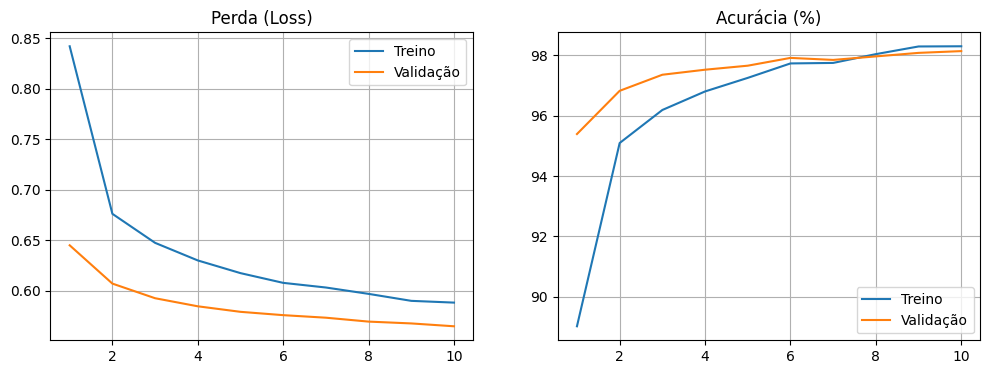

In [6]:
def plot_results(history):
    epochs = range(1, len(history["train_loss"]) + 1)
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

    # Gráfico de Perda
    ax1.plot(epochs, history["train_loss"], label="Treino")
    ax1.plot(epochs, history["val_loss"], label="Validação")
    ax1.grid(True)
    ax1.set_title("Perda (Loss)")
    ax1.legend()

    # Gráfico de Acurácia
    ax2.plot(epochs, history["train_acc"], label="Treino")
    ax2.plot(epochs, history["val_acc"], label="Validação")
    ax2.grid(True)
    ax2.set_title("Acurácia (%)")
    ax2.legend()
    plt.show()

plot_results(history)